# FARGOpy
## Wrapping FARGO3D

## Test:  Interpolation Test 01

### What's in this notebook

This notebook demonstrates how to quantitatively evaluate the quality of interpolation of simulated protoplanetary disk data using FARGOpy. Leave-One-Out (LOO) cross-validation techniques are applied in 1D, 2D, and 3D to estimate the accuracy of the interpolation methods used. Standard metrics such as MAE, MSE, RMSE, and mean relative error are calculated, and residuals are visualized to identify possible biases or problematic regions. The validity and reliability of using LOO in this context is also justified, and examples of parallelization are provided to accelerate the analysis in 3D.

# Leave-One-Location-Out cross-validation and error metrics for 1D,2D,3D interpolation

In this work, the Leave-One-Location-Out cross-validation (LOLO-CV) method is used to evaluate the quality of the interpolation of three-dimensional physical fields obtained from hydrodynamic simulations with FARGO3D on an irregular grid in spherical coordinates. Since the data exhibit spatial correlation, traditional cross-validation methods such as random selection or standard k-fold are inadequate, as they introduce optimistic bias by allowing spatially close points to appear simultaneously in both training and test sets.

LOLO-CV overcomes this issue by iteratively excluding each point from the domain, interpolating its value using the remaining data, and comparing it with the simulated value. This strategy provides a realistic estimate of out-of-sample error and allows for the identification of localized regions with systematic interpolation errors, such as zones with strong gradients or discontinuities. It also maximizes the use of available data, which is essential in numerical simulation contexts where each evaluation is computationally expensive.

The use of LOLO-CV is supported by specialized literature, particularly by Watson et al. (2020), who show that this approach yields more conservative and accurate interpolation error estimates in the presence of complex spatial structures. It also aligns with the methodological recommendations found in classical references such as The Elements of Statistical Learning (Hastie et al., 2013), where pointwise cross-validation is advocated in contexts where accuracy and reproducibility are essential.

## Quantitative evaluation of interpolation quality

To quantify the quality of the interpolation applied to the protoplanetary disk data, a Leave-One-Out (LOO) cross-validation was implemented on the 1D(r, density), 2D cut (x, z, density) or 3D(x, y, z, density). This method consists of:

- Removing one point from the original sample.
- Interpolating the value of that point using the rest of the data.
- Comparing the interpolated value with the real value.
- Repeating the process for all points in the dataset.

This approach is especially robust for small or irregular datasets, such as those resulting from numerical simulations on non-uniform meshes. It allows for a realistic estimation of interpolation error, since each point is evaluated as if it were unknown.

The following statistical metrics were calculated to quantify the error:

- **MAE (Mean Absolute Error):** Average of the absolute value of the errors.
- **MSE (Mean Squared Error):** Average of the squared errors.
- **RMSE (Root Mean Squared Error):** Square root of the MSE, useful for interpreting the error in the same units as the original variable.
- **Mean relative error:** Average of the absolute relative error with respect to the real value, expressed as a percentage.

In addition, the distribution of the residuals (difference between real and interpolated value) was visualized using a histogram, which allows for the identification of possible biases or the presence of outliers.

This analysis provides a quantitative and visual validation of the interpolation quality, which is essential to ensure the reliability of scientific results derived from these data, especially in regions with abrupt gradients or shocks.

### Let's `FARGOpy`

For this tutorial you will need the following external modules and tools:

In [ ]:
import fargopy as fp
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
    
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load the simulation

In [ ]:
fp.Simulation.download_precomputed(setup='p3disoj')
sim = fp.Simulation(output_dir='/tmp/p3disoj')

# 1D Interpolation


Load the simulated data for interpolation

In [51]:
data1d = sim.load_field(
    fields=['gasdens'],
    slice='phi=0,theta=1.56',
    snapshot=10,
    interpolate=True
)

Define the spatial domain of the simulation


In [52]:
xsim = data1d.var1_mesh[0]
ysim = data1d.var2_mesh[0]
zsim = data1d.var3_mesh[0]

rsim = np.sqrt(xsim**2 + ysim**2 + zsim**2)

rho1d = data1d.gasdens_mesh[0]

Interpolate the data on the previously define domain

In [53]:
rho1d_interp = data1d.evaluate(
    time=10,
    var1=rsim,
    interpolator='griddata',
    method='cubic')

Running FARGOpy version 0.4.0


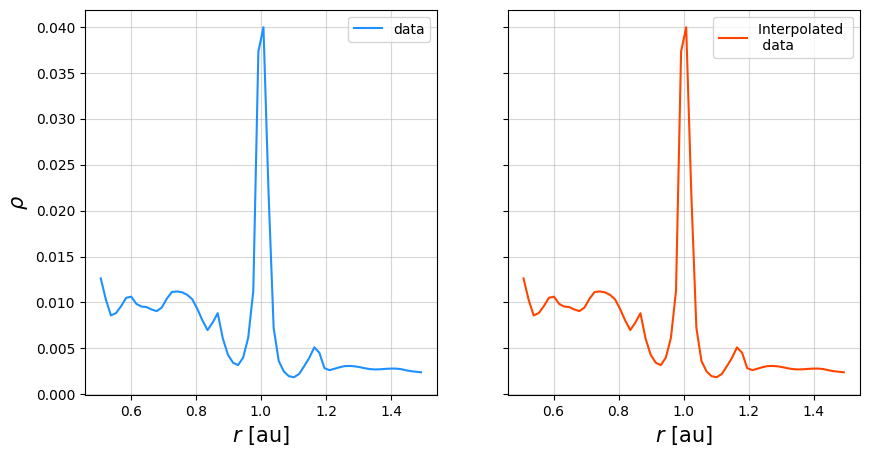

In [6]:
fig,axs = plt.subplots(1,2,figsize=(10,5),sharex=True,sharey=True) 
axs[0].plot(rsim,rho1d,color='dodgerblue',label='data')
axs[1].plot(rsim,rho1d_interp,color='orangered',label='Interpolated \n data')

for i in range(2):
    axs[i].grid(alpha=0.5) 
    axs[i].legend()
    axs[i].set_xlabel(f'$r$ [au]',size=15)
    axs[0].set_ylabel(r'$\rho$',size=15)

plt.show()

MAE (1D): 5.691e-04
MSE (1D): 2.710e-06
RMSE (1D): 1.646e-03
Mean relative error (1D): 6.578%


MAE (1D): 5.691e-04
MSE (1D): 2.710e-06
RMSE (1D): 1.646e-03
Mean relative error (1D): 6.578%


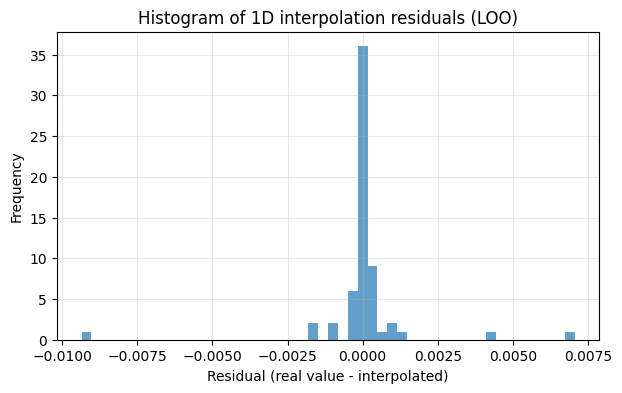

MAE (1D, log10): 3.067e-02
MSE (1D, log10): 6.680e-03
RMSE (1D, log10): 8.173e-02


In [55]:
from sklearn.model_selection import LeaveOneOut
from scipy.interpolate import griddata

# 1D data: r vs density
r_points = rsim.flatten()
values_1d = rho1d.flatten()

loo_1d = LeaveOneOut()
errors_1d = []
rel_errors_1d = []
true_vals_1d = []
pred_vals_1d = []

for train_idx, test_idx in loo_1d.split(r_points.reshape(-1, 1)):
    train_r, test_r = r_points[train_idx], r_points[test_idx]
    train_val, test_val = values_1d[train_idx], values_1d[test_idx]
    interp_val = griddata(train_r, train_val, test_r, method='cubic')
    if np.isnan(interp_val):
        continue
    error = test_val[0] - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_val[0]) if test_val[0] != 0 else np.nan
    errors_1d.append(error)
    rel_errors_1d.append(rel_error)
    true_vals_1d.append(test_val[0])
    pred_vals_1d.append(interp_val[0])

errors_1d = np.array(errors_1d)
rel_errors_1d = np.array(rel_errors_1d)

mae_1d = np.mean(np.abs(errors_1d))
mse_1d = np.mean(errors_1d**2)
rmse_1d = np.sqrt(mse_1d)
mean_rel_error_1d = np.nanmean(rel_errors_1d)

print(f"MAE (1D): {mae_1d:.3e}")
print(f"MSE (1D): {mse_1d:.3e}")
print(f"RMSE (1D): {rmse_1d:.3e}")
print(f"Mean relative error (1D): {mean_rel_error_1d:.3%}")

plt.figure(figsize=(7,4))
plt.hist(errors_1d, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 1D interpolation residuals (LOO)')
plt.grid(alpha=0.3)
plt.show()



# 2D Interpolation

In [18]:
data2d = sim.load_field(
    fields=['gasdens'],
    slice='phi=0',
    snapshot=10,
    interpolate=True
)

xsim= data2d.var1_mesh[0]
ysim = data2d.var2_mesh[0]
zsim = data2d.var3_mesh[0]
rho2dsim = data2d.gasdens_mesh[0]

In [19]:
rho2d_interp= data2d.evaluate(
    time=10,
    var1=xsim,
    var3=zsim,
    interpolator='griddata',
    method='linear')

Running FARGOpy version 0.4.0


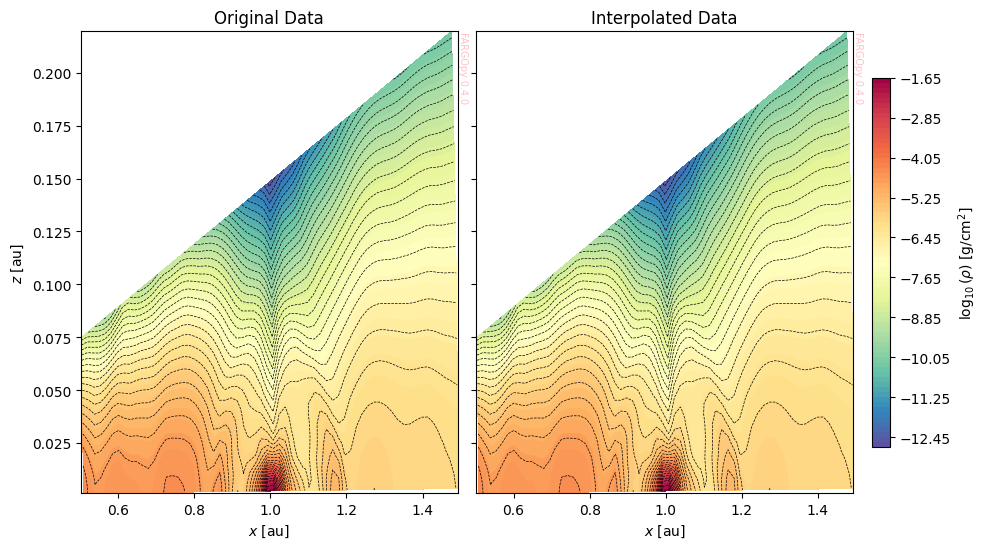

In [20]:
fig, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, gridspec_kw={'width_ratios': [1, 1], 'wspace': 0.05})

cmap = 'Spectral_r'

# Interpolated data
pc1 = axs[0].contourf(xsim, zsim, np.log(rho2dsim), cmap=cmap, levels=100)
axs[0].contour(xsim, zsim, np.log(rho2dsim), levels=50, colors='k', linewidths=0.5)
axs[0].set_xlabel('$x$ [au]')
axs[0].set_ylabel('$z$ [au]')
axs[0].set_title('Original Data')
fp.Plot.fargopy_mark(axs[0])

# Interpolated data
pc2 = axs[1].contourf(xsim, zsim, np.log(rho2d_interp), cmap=cmap, levels=100)
axs[1].contour(xsim, zsim, np.log(rho2d_interp), levels=50, colors='k', linewidths=0.5)
axs[1].set_xlabel('$x$ [au]')
axs[1].set_title('Interpolated Data')
fp.Plot.fargopy_mark(axs[1])

# Shared colorbar
cbar = fig.colorbar(pc2, ax=axs, location='right', shrink=0.8, pad=0.02)
cbar.set_label(r'$\log_{10}(\rho)$ [g/cm$^2$]')

plt.tight_layout()
plt.show()

MAE: 1.133e-04
MSE: 2.870e-06
RMSE: 1.694e-03
Mean relative error: 0.630%


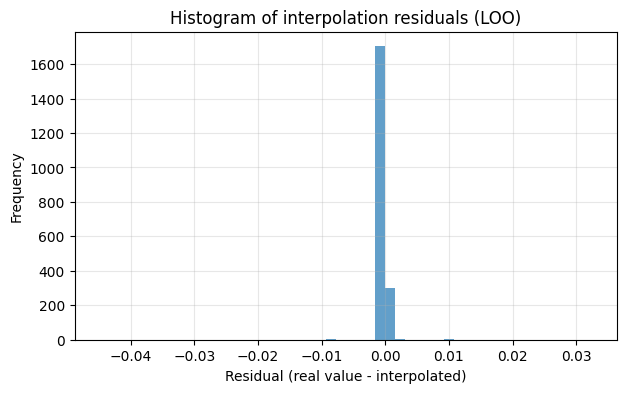

In [21]:
from sklearn.model_selection import LeaveOneOut
from scipy.interpolate import griddata

# Flatten the original data to work with individual points
data_points = np.column_stack((xsim.flatten(), zsim.flatten()))
values = rho2dsim.flatten()

loo = LeaveOneOut()
errors = []
rel_errors = []
true_vals = []
pred_vals = []

for train_idx, test_idx in loo.split(data_points):
    train_points, test_point = data_points[train_idx], data_points[test_idx]
    train_values, test_value = values[train_idx], values[test_idx]
    interp_value = griddata(train_points, train_values, test_point, method='cubic')
    if np.isnan(interp_value):
        continue  # Skip points outside the interpolable domain
    error = test_value[0] - interp_value[0]
    rel_error = np.abs(error) / np.abs(test_value[0]) if test_value[0] != 0 else np.nan
    errors.append(error)
    rel_errors.append(rel_error)
    true_vals.append(test_value[0])
    pred_vals.append(interp_value[0])

errors = np.array(errors)
rel_errors = np.array(rel_errors)

mae = np.mean(np.abs(errors))
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mean_rel_error = np.nanmean(rel_errors)

print(f"MAE: {mae:.3e}")
print(f"MSE: {mse:.3e}")
print(f"RMSE: {rmse:.3e}")
print(f"Mean relative error: {mean_rel_error:.3%}")

# Residuals visualization
plt.figure(figsize=(7,4))
plt.hist(errors, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of interpolation residuals (LOO)')
plt.grid(alpha=0.3)
plt.show()

# 2D LOG METRICS
eps = 1e-12
log_true_2d = np.log10(np.clip(true_vals, eps, None))
log_pred_2d = np.log10(np.clip(pred_vals, eps, None))

mae_2d_log = np.mean(np.abs(log_true_2d - log_pred_2d))
mse_2d_log = np.mean((log_true_2d - log_pred_2d)**2)
rmse_2d_log = np.sqrt(mse_2d_log)

print(f"MAE (2D, log10): {mae_2d_log:.3e}")
print(f"MSE (2D, log10): {mse_2d_log:.3e}")
print(f"RMSE (2D, log10): {rmse_2d_log:.3e}")

# 3D Interpolation


In [29]:
data3d = sim.load_field(
    fields=['gasdens'],
    snapshot=10,
    interpolate=True
)

Loading density field


In [38]:
xsim = data3d.var1_mesh[0]
ysim = data3d.var2_mesh[0]
zsim = data3d.var3_mesh[0]
rho3dsim = data3d.gasdens_mesh[0]   

In [39]:
rho3d_interp = data3d.evaluate(
    time=10,
    var1=xsim,
    var2=ysim,
    var3=zsim,
    interpolator='idw',
    idw_kwargs={'power': 4,'k':40}
)   



Running FARGOpy version 0.4.0


Define our model for 3D interpolation

In [40]:
from scipy.spatial import cKDTree

def idw_interp(coords, values, xi,power=4, k=40):
    # Force to 2D: (N, D) and (M, D)
    coords = np.asarray(coords)
    xi = np.asarray(xi)
    if coords.ndim > 2:
        coords = coords.reshape(-1, coords.shape[-1])
    if xi.ndim > 2:
        xi = xi.reshape(-1, xi.shape[-1])
    values = np.asarray(values).ravel()

    tree = cKDTree(coords)
    dists, idxs = tree.query(xi, k=k)
    dists = np.where(dists == 0, 1e-10, dists)
    weights = 1 / dists**power
    weights /= weights.sum(axis=1, keepdims=True)
    interp_values = np.sum(values[idxs] * weights, axis=1)

    return interp_values

## Parallelization of Leave-One-Out cross-validation in 3D

Given the high computational cost of Leave-One-Out validation in 3D, it is possible to speed up the process using the `joblib` library to parallelize the calculation. This allows multiple processor cores to be used and significantly reduces execution time. Below is an example of how to implement cross-validation in parallel on a random sample of points.

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 8 concurrent workers.


[Parallel(n_jobs=-1)]: Done   2 tasks      | elapsed:    1.1s
[Parallel(n_jobs=-1)]: Done   9 tasks      | elapsed:    1.3s
[Parallel(n_jobs=-1)]: Done  16 tasks      | elapsed:    1.4s
[Parallel(n_jobs=-1)]: Done  25 tasks      | elapsed:    1.6s
[Parallel(n_jobs=-1)]: Done  34 tasks      | elapsed:    1.7s
[Parallel(n_jobs=-1)]: Done  45 tasks      | elapsed:    1.9s
[Parallel(n_jobs=-1)]: Done  56 tasks      | elapsed:    2.0s
[Parallel(n_jobs=-1)]: Done  69 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done  82 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done  97 tasks      | elapsed:    2.6s
[Parallel(n_jobs=-1)]: Done 112 tasks      | elapsed:    2.8s
[Parallel(n_jobs=-1)]: Done 129 tasks      | elapsed:    3.2s
[Parallel(n_jobs=-1)]: Done 146 tasks      | elapsed:    3.4s
[Parallel(n_jobs=-1)]: Done 165 tasks      | elapsed:    3.7s
[Parallel(n_jobs=-1)]: Done 184 tasks      | elapsed:    4.0s
[Parallel(n_jobs=-1)]: Done 205 tasks      | elapsed:    4.3s
[Paralle

MAE (3D, sample): 1.679e-04
MSE (3D, sample): 3.460e-07
RMSE (3D, sample): 5.882e-04
Mean relative error (3D, sample): 12.617%
Excluded 9192 points with |true value| <= 0.0001


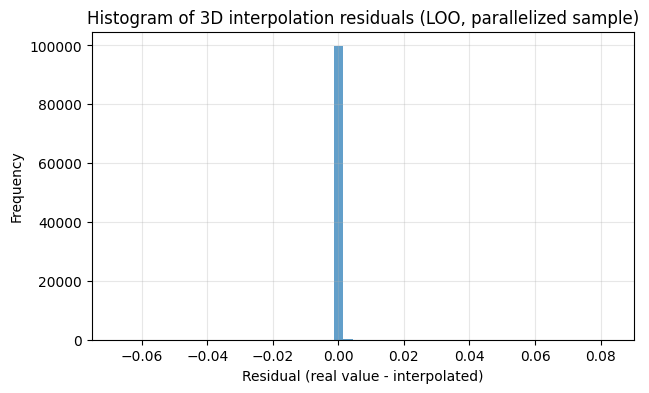

In [48]:
from joblib import Parallel, delayed
import numpy as np
from scipy.interpolate import griddata
from sklearn.model_selection import LeaveOneOut


# 3D data: (x, y, z) vs density
x3d = xsim.flatten()
y3d = ysim.flatten()
z3d = zsim.flatten()
values_3d = rho3dsim.flatten()

points_3d = np.column_stack((x3d, y3d, z3d))

loo_3d = LeaveOneOut()
# Parameters
n_sample = 100000 # Number of points to randomly sample
n_jobs = -1      # Use all available cores

# Random selection of points
rng = np.random.default_rng(67)
N = points_3d.shape[0]
idx_sample = rng.choice(N, size=n_sample, replace=False)
points_sample = points_3d[idx_sample]
values_sample = values_3d[idx_sample]

# Function for Leave-One-Out on a point
def loo_error(i):
    mask = np.arange(n_sample) != i
    train_points = points_sample[mask]
    train_values = values_sample[mask]
    test_point = points_sample[i].reshape(1, -1)
    test_value = values_sample[i]
    #interp_val = griddata(train_points, train_values, test_point, method='nearest')
    interp_val = idw_interp(train_points, train_values, test_point,power=4,k=80)
    if np.isnan(interp_val):
        return None
    error = test_value - interp_val[0]
    rel_error = np.abs(error) / np.abs(test_value) if test_value != 0 else np.nan
    return error, rel_error, test_value, interp_val[0]

results = Parallel(n_jobs=n_jobs, verbose=10)(delayed(loo_error)(i) for i in range(n_sample))

results = [r for r in results if r is not None]
errors_3d, rel_errors_3d, true_vals_3d, pred_vals_3d = map(np.array, zip(*results))

mae_3d = np.mean(np.abs(errors_3d))
mse_3d = np.mean(errors_3d**2)
rmse_3d = np.sqrt(mse_3d)

# Improved mean relative error calculation: ignore very small true values
tol = 1e-4  # Use a value 1-2 orders of magnitude below your minimum, e.g. 1e-5 for your range
valid = np.abs(true_vals_3d) > tol
rel_errors = np.full_like(errors_3d, np.nan, dtype=np.float64)
rel_errors[valid] = np.abs(errors_3d[valid]) / np.abs(true_vals_3d[valid])

mean_rel_error_3d = np.nanmean(rel_errors)


print(f"MAE (3D, sample): {mae_3d:.3e}")
print(f"MSE (3D, sample): {mse_3d:.3e}")
print(f"RMSE (3D, sample): {rmse_3d:.3e}")
print(f"Mean relative error (3D, sample): {mean_rel_error_3d:.3%}")

excluded = np.sum(~valid)
print(f"Excluded {excluded} points with |true value| <= {tol}")

plt.figure(figsize=(7,4))
plt.hist(errors_3d, bins=50, alpha=0.7)
plt.xlabel('Residual (real value - interpolated)')
plt.ylabel('Frequency')
plt.title('Histogram of 3D interpolation residuals (LOO, parallelized sample)')
plt.grid(alpha=0.3)
plt.show()

# 3D LOG METRICS
eps = 1e-12
log_true_3d = np.log10(np.clip(true_vals_3d, eps, None))
log_pred_3d = np.log10(np.clip(pred_vals_3d, eps, None))

mae_3d_log = np.mean(np.abs(log_true_3d - log_pred_3d))
mse_3d_log = np.mean((log_true_3d - log_pred_3d)**2)
rmse_3d_log = np.sqrt(mse_3d_log)

print(f"MAE (3D, log10): {mae_3d_log:.3e}")
print(f"MSE (3D, log10): {mse_3d_log:.3e}")
print(f"RMSE (3D, log10): {rmse_3d_log:.3e}")